# MLP com PyTorch — Comparação com XGBoost
### Cancelamento de Serviços Operacionais

**Objetivo:** Treinar uma rede neural MLP com PyTorch nas mesmas condições do
notebook `03_modeling.ipynb` e comparar com o XGBoost para verificar
empiricamente qual modelo é mais adequado para este problema tabular.

**Referência (XGBoost — notebook 03):**
| Métrica | CV 5-fold | Teste |
|---|---|---|
| AUC-ROC | 0.771 ± 0.006 | 0.758 |
| Average Precision | 0.573 ± 0.011 | 0.554 |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

FIGURES = Path('../reports/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f'Pytorch : {torch.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

df = pd.read_parquet('../data/processed/features_modelo.parquet')
print(f'\nDataset: {df.shape[0]:,} ordens x {df.shape[1]} colunas')

Pytorch : 2.11.0+cu128
Device: cuda

Dataset: 54,613 ordens x 17 colunas


## 2. Separação Temporal Treino / Teste

Idêntico ao notebook `03_modeling.ipynb` — corte em 2020-01-01.

O modelo treina em ordens abertas **até dez/2019** e é avaliado em ordens de
**jan a abr/2020**, simulando o cenário real de produção onde sempre se prevê
o futuro com base no passado.


In [2]:
FEATURES = [
    'prazo_horas', 'priori_num',
    'hora_abertura', 'dia_semana_num', 'mes', 'fim_de_semana', 'fora_horario_com',
    'GRUPO_SERVICO_OPERACIONAL', 'COD_AREA_SERVICO', 'COD_SERVICO_ETAPA',
    'hist_n_ordens', 'hist_n_cancelamentos', 'hist_taxa_cancelamento',
    'hist_recencia_dias', 'hist_reincidencia_90d',
]
TARGET = 'cancelado'

CAT_COLS = ['GRUPO_SERVICO_OPERACIONAL', 'COD_AREA_SERVICO', 'COD_SERVICO_ETAPA']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

CORTE = pd.Timestamp('2020-01-01')
mask_train = df['DATA_REG'] < CORTE
mask_test  = df['DATA_REG'] >= CORTE

X_train_raw = df.loc[mask_train, FEATURES]
X_test_raw  = df.loc[mask_test,  FEATURES]
y_train     = df.loc[mask_train, TARGET].values.astype(np.float32)
y_test      = df.loc[mask_test,  TARGET].values.astype(np.float32)

print(f'Treino : {X_train_raw.shape[0]:,} ordens')
print(f'Teste  : {X_test_raw.shape[0]:,} ordens')
print(f'\nTaxa cancelamento — Treino : {y_train.mean():.2%}')
print(f'Taxa cancelamento — Teste  : {y_test.mean():.2%}')


Treino : 47,640 ordens
Teste  : 6,973 ordens

Taxa cancelamento — Treino : 30.10%
Taxa cancelamento — Teste  : 31.31%


## 3. Preprocessamento

A MLP exige que **todas as features sejam numéricas e na mesma escala**.
Aplicamos dois transformadores:

- **TargetEncoder** nas 3 features categóricas — converte strings em valores
  numéricos baseados na taxa de cancelamento de cada categoria
- **StandardScaler** em todas as features numéricas — centraliza em média 0
  e desvio padrão 1

O XGBoost **não precisa** de nenhum desses passos — árvores são invariantes
a escala e lidam com categorias diretamente. Essa etapa extra já é uma
desvantagem estrutural da MLP.


In [3]:
preprocessor = ColumnTransformer([
    ('te',  TargetEncoder(target_type='binary'), CAT_COLS),
    ('num', StandardScaler(),                    NUM_COLS),
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train_raw, y_train).astype(np.float32)
X_test_proc  = preprocessor.transform(X_test_raw).astype(np.float32)

N_FEATURES = X_train_proc.shape[1]
print(f'Features : {N_FEATURES}')
print(f'Treino   : {X_train_proc.shape}')
print(f'Teste    : {X_test_proc.shape}')


Features : 15
Treino   : (47640, 15)
Teste    : (6973, 15)


## 4. Arquitetura da MLP

Testaremos 3 arquiteturas, da mais simples à mais complexa:

| Arquitetura | Camadas ocultas | Justificativa |
|---|---|---|
| **Simples** | [64, 32] | Mínimo viável |
| **Média** | [128, 64, 32] | Padrão para dados tabulares |
| **Profunda** | [256, 128, 64, 32] | Capacidade máxima testada |

Todas usam:
- **ReLU** — ativação padrão, evita o problema do gradiente desaparecendo
- **BatchNorm** — normaliza a saída de cada camada, estabiliza o treino
- **Dropout(0.3)** — desliga 30% dos neurônios aleatoriamente a cada batch, evita overfitting
- **BCEWithLogitsLoss** — loss para classificação binária com `pos_weight`
  para compensar o desbalanceamento 70/30


In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


def contar_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


arquiteturas = {
    'MLP Simples  [64, 32]':          [64, 32],
    'MLP Media    [128, 64, 32]':     [128, 64, 32],
    'MLP Profunda [256, 128, 64, 32]':[256, 128, 64, 32],
}

for nome, dims in arquiteturas.items():
    m = MLP(N_FEATURES, dims)
    print(f'{nome}  →  {contar_params(m):,} parâmetros')


MLP Simples  [64, 32]  →  3,329 parâmetros
MLP Media    [128, 64, 32]  →  12,865 parâmetros
MLP Profunda [256, 128, 64, 32]  →  48,321 parâmetros


## 5. Loop de Treino com Early Stopping

O early stopping monitora a AUC-ROC na validação a cada época e interrompe
o treino quando não há melhora por `patience` épocas seguidas.

Sem isso a rede continuaria ajustando os pesos indefinidamente e começaria
a memorizar o conjunto de treino — overfitting.


In [5]:
def treinar_mlp(X_tr, y_tr, X_val, y_val, hidden_dims,
                lr=1e-3, batch_size=512, max_epochs=150,
                patience=15, dropout=0.3, verbose=False):

    pos_weight = torch.tensor(
        [(y_tr == 0).sum() / (y_tr == 1).sum()], dtype=torch.float32
    ).to(DEVICE)

    model     = MLP(X_tr.shape[1], hidden_dims, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )

    dataset = TensorDataset(
        torch.from_numpy(X_tr).to(DEVICE),
        torch.from_numpy(y_tr).to(DEVICE),
    )
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    X_val_t = torch.from_numpy(X_val).to(DEVICE)

    best_auc, best_state, no_improve = 0.0, None, 0
    history = []

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_tr)

        model.eval()
        with torch.no_grad():
            probs_val = torch.sigmoid(model(X_val_t)).cpu().numpy()

        val_auc = roc_auc_score(y_val, probs_val)
        scheduler.step(1 - val_auc)
        history.append({'epoch': epoch + 1, 'loss': epoch_loss, 'val_auc': val_auc})

        if val_auc > best_auc:
            best_auc   = val_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Época {epoch+1:3d}  loss={epoch_loss:.4f}  '
                  f'val_auc={val_auc:.4f}  melhor={best_auc:.4f}')

        if no_improve >= patience:
            if verbose:
                print(f'  Early stopping na época {epoch+1}')
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        probs_val = torch.sigmoid(model(X_val_t)).cpu().numpy()

    return {
        'model':    model,
        'auc_roc':  roc_auc_score(y_val, probs_val),
        'avg_prec': average_precision_score(y_val, probs_val),
        'epochs':   epoch + 1,
        'history':  history,
    }

print('Função de treino definida.')


Função de treino definida.


## 6. Validação Cruzada — 5-Fold Estratificado

Mesmo protocolo do `03_modeling.ipynb`: **StratifiedKFold com 5 folds** no
conjunto de treino.

Para garantir comparação justa com o XGBoost, em cada fold:
1. O preprocessador (TargetEncoder + StandardScaler) é refitado **apenas nos
   dados de treino do fold** — sem leakage do target encoding para a validação
2. A MLP é treinada do zero com early stopping
3. As métricas são registradas na validação do fold

Ao final, reportamos a média ± desvio padrão das 5 execuções.

In [6]:
def cv_mlp(nome, hidden_dims, X_raw, y, cv=5, **treino_kwargs):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    fold_aucs, fold_aps, fold_epochs = [], [], []

    for fold, (idx_tr, idx_val) in enumerate(skf.split(X_raw, y)):
        X_f_raw, X_v_raw = X_raw.iloc[idx_tr], X_raw.iloc[idx_val]
        y_f, y_v = y[idx_tr], y[idx_val]

        # Preprocessador refitado dentro do fold — sem leakage
        pre_fold = ColumnTransformer([
            ('te',  TargetEncoder(target_type='binary'), CAT_COLS),
            ('num', StandardScaler(),                    NUM_COLS),
        ], remainder='drop')
        X_f = pre_fold.fit_transform(X_f_raw, y_f).astype(np.float32)
        X_v = pre_fold.transform(X_v_raw).astype(np.float32)

        r = treinar_mlp(X_f, y_f, X_v, y_v, hidden_dims, **treino_kwargs)
        fold_aucs.append(r['auc_roc'])
        fold_aps.append(r['avg_prec'])
        fold_epochs.append(r['epochs'])
        print(f'  Fold {fold+1}: AUC-ROC={r["auc_roc"]:.4f}  '
              f'Avg Prec={r["avg_prec"]:.4f}  epocas={r["epochs"]}')

    metricas = {
        'modelo':            nome,
        'auc_roc':           np.mean(fold_aucs),
        'auc_roc_std':       np.std(fold_aucs),
        'avg_precision':     np.mean(fold_aps),
        'avg_precision_std': np.std(fold_aps),
        'epocas_media':      np.mean(fold_epochs),
    }
    print(f"\n{'='*55}")
    print(f"Modelo: {nome}")
    print(f"  AUC-ROC          : {metricas['auc_roc']:.4f} +/- {metricas['auc_roc_std']:.4f}")
    print(f"  Average Precision: {metricas['avg_precision']:.4f} +/- {metricas['avg_precision_std']:.4f}")
    print(f"  Epocas (media)   : {metricas['epocas_media']:.1f}")
    print(f"{'='*55}\n")
    return metricas


resultados_mlp = []
print('Funcao de CV definida.')

Funcao de CV definida.


### 6.1 MLP Simples — [64, 32]

A arquitetura mínima: duas camadas ocultas pequenas. Se até ela chegar perto
do XGBoost, o problema não precisa de complexidade. Se ficar muito abaixo,
tentamos arquiteturas maiores.

In [7]:
t0 = time.time()
m = cv_mlp('MLP Simples [64,32]', [64, 32],
           X_raw=X_train_raw, y=y_train,
           lr=1e-3, batch_size=512, max_epochs=150, patience=15)
print(f'Tempo: {time.time()-t0:.1f}s')
resultados_mlp.append(m)

  Fold 1: AUC-ROC=0.7569  Avg Prec=0.5275  epocas=105
  Fold 2: AUC-ROC=0.7654  Avg Prec=0.5329  epocas=100
  Fold 3: AUC-ROC=0.7631  Avg Prec=0.5432  epocas=112
  Fold 4: AUC-ROC=0.7459  Avg Prec=0.5247  epocas=82
  Fold 5: AUC-ROC=0.7405  Avg Prec=0.5091  epocas=99

Modelo: MLP Simples [64,32]
  AUC-ROC          : 0.7544 +/- 0.0097
  Average Precision: 0.5275 +/- 0.0111
  Epocas (media)   : 99.6

Tempo: 144.7s


### 6.2 MLP Média — [128, 64, 32]

Arquitetura padrão citada na literatura para dados tabulares. Três camadas
com capacidade progressivamente menor — força a rede a compactar a
representação antes da saída.

In [8]:
t0 = time.time()
m = cv_mlp('MLP Media [128,64,32]', [128, 64, 32],
           X_raw=X_train_raw, y=y_train,
           lr=1e-3, batch_size=512, max_epochs=150, patience=15)
print(f'Tempo: {time.time()-t0:.1f}s')
resultados_mlp.append(m)

  Fold 1: AUC-ROC=0.7568  Avg Prec=0.5290  epocas=54
  Fold 2: AUC-ROC=0.7652  Avg Prec=0.5347  epocas=89
  Fold 3: AUC-ROC=0.7657  Avg Prec=0.5500  epocas=78
  Fold 4: AUC-ROC=0.7449  Avg Prec=0.5266  epocas=66
  Fold 5: AUC-ROC=0.7408  Avg Prec=0.5103  epocas=93

Modelo: MLP Media [128,64,32]
  AUC-ROC          : 0.7547 +/- 0.0103
  Average Precision: 0.5301 +/- 0.0128
  Epocas (media)   : 76.0

Tempo: 117.1s


### 6.3 MLP Profunda — [256, 128, 64, 32]

Máxima capacidade testada. Se mais parâmetros não ajudarem, fica confirmado
que o gargalo não é capacidade da rede — é o tipo de problema.

In [9]:
t0 = time.time()
m = cv_mlp('MLP Profunda [256,128,64,32]', [256, 128, 64, 32],
           X_raw=X_train_raw, y=y_train,
           lr=1e-3, batch_size=512, max_epochs=150, patience=15)
print(f'Tempo: {time.time()-t0:.1f}s')
resultados_mlp.append(m)

  Fold 1: AUC-ROC=0.7579  Avg Prec=0.5318  epocas=73
  Fold 2: AUC-ROC=0.7649  Avg Prec=0.5356  epocas=49
  Fold 3: AUC-ROC=0.7634  Avg Prec=0.5456  epocas=99
  Fold 4: AUC-ROC=0.7466  Avg Prec=0.5270  epocas=64
  Fold 5: AUC-ROC=0.7406  Avg Prec=0.5096  epocas=83

Modelo: MLP Profunda [256,128,64,32]
  AUC-ROC          : 0.7547 +/- 0.0095
  Average Precision: 0.5299 +/- 0.0118
  Epocas (media)   : 73.6

Tempo: 122.3s


## 7. Avaliação no Conjunto de Teste

A melhor arquitetura do CV é retreinada no treino completo e avaliada no
conjunto de teste (jan–abr/2020) — o mesmo protocolo do `03_modeling.ipynb`.

Esse é o número definitivo para comparar com o XGBoost: ambos viram os mesmos
dados de treino e são avaliados no mesmo conjunto futuro.

In [10]:
dims_map = {
    'MLP Simples [64,32]':           [64, 32],
    'MLP Media [128,64,32]':         [128, 64, 32],
    'MLP Profunda [256,128,64,32]':  [256, 128, 64, 32],
}

melhor = max(resultados_mlp, key=lambda r: r['auc_roc'])
print(f"Melhor arquitetura no CV : {melhor['modelo']}")
print(f"AUC-ROC CV               : {melhor['auc_roc']:.4f} +/- {melhor['auc_roc_std']:.4f}")

print(f'\nTreinando no treino completo e avaliando no teste...')
t0 = time.time()
resultado_teste = treinar_mlp(
    X_train_proc, y_train,
    X_test_proc,  y_test,
    dims_map[melhor['modelo']],
    lr=1e-3, batch_size=512, max_epochs=150, patience=15, verbose=True,
)
print(f'\nTempo: {time.time()-t0:.1f}s')
print(f'\n--- Resultado no conjunto de teste ---')
print(f'AUC-ROC          : {resultado_teste["auc_roc"]:.4f}')
print(f'Average Precision: {resultado_teste["avg_prec"]:.4f}')
print(f'Epocas treinadas : {resultado_teste["epochs"]}')

Melhor arquitetura no CV : MLP Profunda [256,128,64,32]
AUC-ROC CV               : 0.7547 +/- 0.0095

Treinando no treino completo e avaliando no teste...
  Época  10  loss=0.8332  val_auc=0.7419  melhor=0.7419
  Época  20  loss=0.8253  val_auc=0.7452  melhor=0.7452
  Época  30  loss=0.8239  val_auc=0.7434  melhor=0.7462
  Early stopping na época 39

Tempo: 15.3s

--- Resultado no conjunto de teste ---
AUC-ROC          : 0.7462
Average Precision: 0.5451
Epocas treinadas : 39


## 8. Comparação Final — MLP vs XGBoost

Consolidação de todas as arquiteturas MLP contra o XGBoost nas mesmas métricas
e no mesmo protocolo de validação.

In [11]:
# Resultados do XGBoost registrados no notebook 03_modeling.ipynb
xgb_cv = {
    'modelo': 'XGBoost (referencia)',
    'auc_roc': 0.771, 'auc_roc_std': 0.006,
    'avg_precision': 0.573, 'avg_precision_std': 0.011,
}

df_comp = pd.DataFrame(resultados_mlp + [xgb_cv])[[
    'modelo', 'auc_roc', 'auc_roc_std', 'avg_precision', 'avg_precision_std'
]].sort_values('auc_roc', ascending=False).reset_index(drop=True)

print('CV 5-fold — treino:')
print(df_comp.to_string(index=False))

print(f'\nTeste — Melhor MLP   : AUC-ROC={resultado_teste["auc_roc"]:.4f}  '
      f'Avg Prec={resultado_teste["avg_prec"]:.4f}')
print(f'Teste — XGBoost      : AUC-ROC=0.7580  Avg Prec=0.5540')

CV 5-fold — treino:
                      modelo  auc_roc  auc_roc_std  avg_precision  avg_precision_std
        XGBoost (referencia)   0.7710       0.0060         0.5730             0.0110
MLP Profunda [256,128,64,32]   0.7547       0.0095         0.5299             0.0118
       MLP Media [128,64,32]   0.7547       0.0103         0.5301             0.0128
         MLP Simples [64,32]   0.7544       0.0097         0.5275             0.0111

Teste — Melhor MLP   : AUC-ROC=0.7462  Avg Prec=0.5451
Teste — XGBoost      : AUC-ROC=0.7580  Avg Prec=0.5540


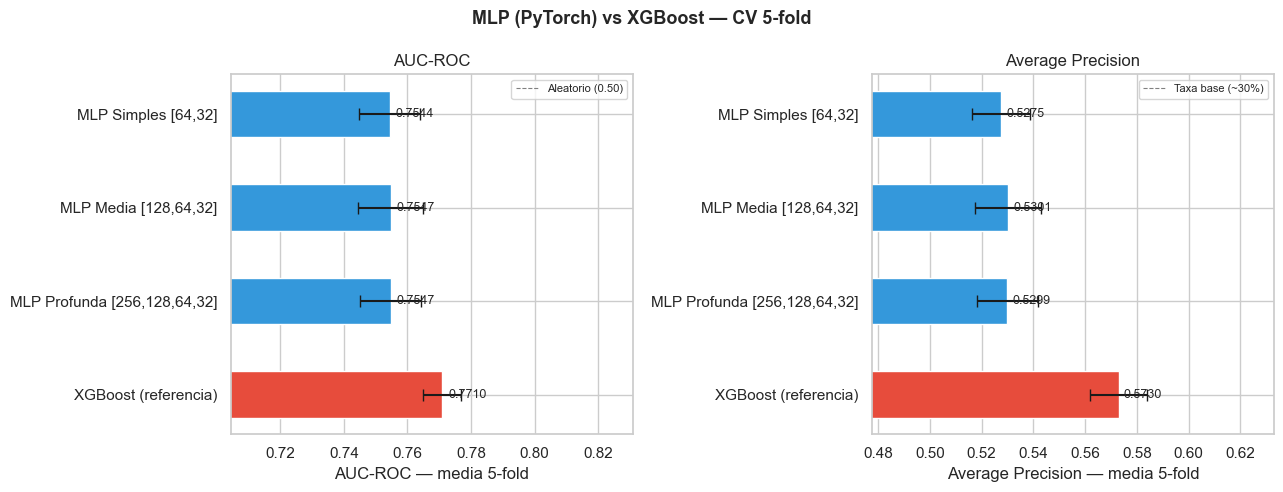

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos = df_comp['modelo'].tolist()
cores   = ['#e74c3c' if 'XGBoost' in m else '#3498db' for m in modelos]
y_pos   = np.arange(len(modelos))

for ax, metrica, std_col, titulo, linha_ref, label_ref in [
    (axes[0], 'auc_roc',       'auc_roc_std',       'AUC-ROC',           0.50,   'Aleatorio (0.50)'),
    (axes[1], 'avg_precision', 'avg_precision_std', 'Average Precision',  0.3025, 'Taxa base (~30%)'),
]:
    ax.barh(y_pos, df_comp[metrica], xerr=df_comp[std_col],
            color=cores, capsize=4, height=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(modelos)
    ax.set_xlabel(f'{titulo} — media 5-fold')
    ax.set_title(titulo)
    ax.axvline(linha_ref, color='gray', linestyle='--', linewidth=0.8, label=label_ref)
    for i, v in enumerate(df_comp[metrica]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
    ax.set_xlim(df_comp[metrica].min() - 0.05, df_comp[metrica].max() + 0.06)
    ax.legend(fontsize=8)

fig.suptitle('MLP (PyTorch) vs XGBoost — CV 5-fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '04_mlp_vs_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Curva de Aprendizado da Melhor MLP

Mostra como a AUC-ROC na validação evolui ao longo das épocas durante o
treino final. Revela se a rede convergiu de forma estável ou oscilou —
e em que ponto o early stopping interrompeu.

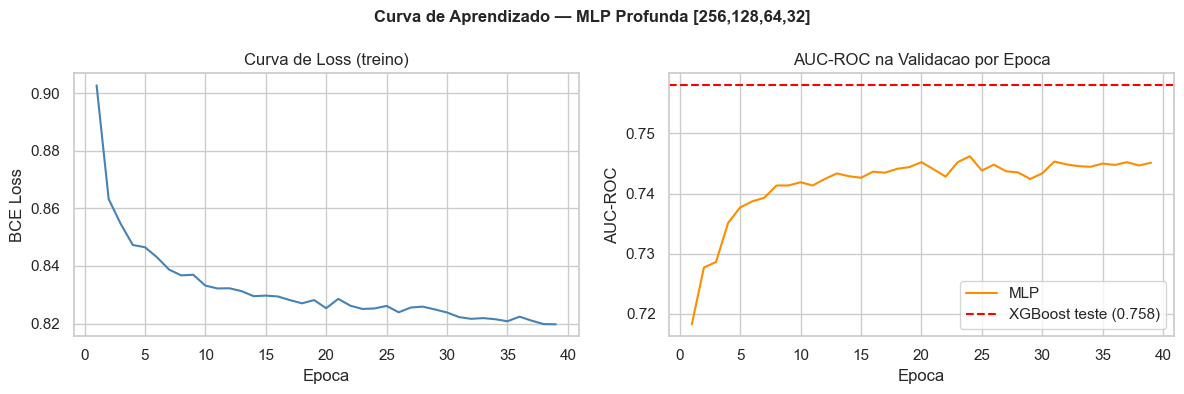

In [13]:
hist_df = pd.DataFrame(resultado_teste['history'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df['epoch'], hist_df['loss'], color='steelblue')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Curva de Loss (treino)')

axes[1].plot(hist_df['epoch'], hist_df['val_auc'], color='darkorange', label='MLP')
axes[1].axhline(0.758, color='red', linestyle='--', linewidth=1.5,
                label='XGBoost teste (0.758)')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC na Validacao por Epoca')
axes[1].legend()

plt.suptitle(f'Curva de Aprendizado — {melhor["modelo"]}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '04_curva_aprendizado.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusão

### Resumo dos resultados

| Modelo | AUC-ROC CV | Avg Prec CV | AUC-ROC Teste | Avg Prec Teste |
|---|---|---|---|---|
| **XGBoost** | **0.771 ± 0.006** | **0.573 ± 0.011** | **0.758** | **0.554** |
| MLP Profunda [256,128,64,32] | 0.755 ± 0.010 | 0.530 ± 0.012 | 0.746 | 0.545 |
| MLP Média [128,64,32] | 0.755 ± 0.010 | 0.530 ± 0.013 | — | — |
| MLP Simples [64,32] | 0.754 ± 0.010 | 0.528 ± 0.011 | — | — |

**Gap XGBoost vs melhor MLP:** +1.6pp AUC-ROC no CV, +4.3pp Average Precision no CV.

**Detalhe relevante:** as três arquiteturas MLP têm performance quase idêntica —
dobrar os parâmetros (3k → 48k) não trouxe nenhum ganho. O gargalo não é
capacidade da rede, é o tipo de problema.

### Por que o XGBoost vence neste problema

| Fator | MLP | XGBoost |
|---|---|---|
| **Escala das features** | Obrigatório normalizar | Invariante — árvores não usam distância |
| **Variáveis categóricas** | Precisa de encoding externo | TargetEncoder nativo no pipeline |
| **Volume de dados** | Beneficia de +1M amostras | Ótimo para dezenas de milhares |
| **Interações entre features** | Aprende implicitamente (pode não capturar) | Splits capturam diretamente |
| **Regularização** | Dropout, BatchNorm, weight_decay — mais hiperparâmetros | `max_depth`, `subsample` — mais direto |
| **Interpretabilidade** | SHAP possível, mas custoso | TreeSHAP nativo e eficiente |
| **Tempo de treino** | ~6min para 3 arquiteturas × 5 folds | Segundos no mesmo hardware |

### Quando uma MLP valeria reconsiderar

- Volume crescer **10× ou mais** (~500k+ ordens)
- Inclusão de dados não estruturados: texto de campos de observação, fotos
- Arquiteturas especializadas em tabular: **TabNet** ou **FT-Transformer**

**Conclusão:** A escolha pelo XGBoost no notebook `03_modeling.ipynb` é
confirmada empiricamente. Para este problema, com este volume e estas features,
o XGBoost é o modelo correto.